In [4]:
# Importing pandasfor data cleaning, matplotlib for creating charts, and joblib for saving objects
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Importing sklearn library methods for splitting data, scaling features, training models, tuning parameters, and scoring results
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Importing wartnings to filter out warning messages that are non-fatal
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Loading the dataset
dataframe = pd.read_csv(r"C:\Users\balap\anaconda_projects\Customer_Churn_Prediction_Project\customer_churn_data.csv")

In [6]:
# Checking categories and datatypes in dataset
display(dataframe.head())
display(dataframe.tail())
display(dataframe.info())

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


None

In [7]:
# Checking for missing values
dataframe.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [8]:
# Filling in the missing values rather than dropping the values since we might be missing crucial information by droping that many values
dataframe["InternetService"] = dataframe["InternetService"].fillna("")
dataframe.isna().sum()


CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [9]:
#Checking for duplicate values
dataframe.duplicated().sum()

np.int64(0)

In [38]:
# Funnel Analysis (Customer Lifecycle)

# Total customers
total_customers = len(dataframe)

# Churned customers (assuming Yes/No)
churned_customers = dataframe[dataframe["Churn"] == "Yes"].shape[0]

# Retained customers
retained_customers = dataframe[dataframe["Churn"] == "No"].shape[0]

# At-risk customers (low tenure threshold)
at_risk_customers = dataframe[dataframe["Tenure"] < 6].shape[0]

# Create funnel table
funnel_df = pd.DataFrame({
    "Stage": ["Total Customers", "Retained", "At Risk (Tenure < 6)", "Churned"],
    "Count": [total_customers, retained_customers, at_risk_customers, churned_customers]
})

display(funnel_df)

,Stage,Count
0,Total Customers,1000
1,Retained,117
2,At Risk (Tenure < 6),252
3,Churned,883


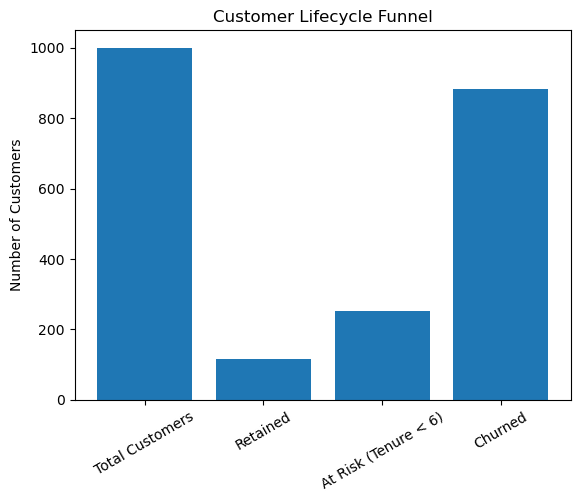

In [39]:
plt.figure()
plt.bar(funnel_df["Stage"], funnel_df["Count"])
plt.title("Customer Lifecycle Funnel")
plt.xticks(rotation=30)
plt.ylabel("Number of Customers")
plt.show()

In [40]:
# Tenure-Based Retention Analysis (Cohort Proxy)

# Create tenure groups
dataframe["Tenure_Group"] = pd.cut(
    dataframe["Tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6", "6-12", "12-24", "24-48", "48-72"],
    include_lowest=True
)

# Build churn distribution by tenure group
tenure_analysis = (
    dataframe.groupby("Tenure_Group")["Churn"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# Make sure the columns are clearly named
tenure_analysis = tenure_analysis.rename(columns={"No": "Retained", "Yes": "Churned"})

# Show the final table
display(tenure_analysis)

Churn,Retained,Churned
Tenure_Group,,
0-6,0.000000,1.000000
6-12,0.021053,0.978947
12-24,0.231760,0.768240
24-48,0.219895,0.780105
48-72,0.200000,0.800000


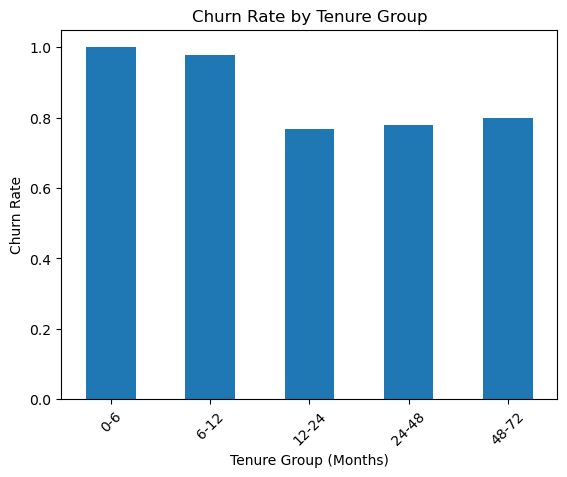

In [41]:
# Visualization of churn by tenure group
tenure_analysis["Churned"].plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group (Months)")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Getting the fuve number summary for the dataset
dataframe.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [11]:
# Printing the column names prior to modeling
dataframe.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [12]:
# Checking the correlation between the numeric columns
numeric_columns_data = dataframe.select_dtypes(include="number")
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


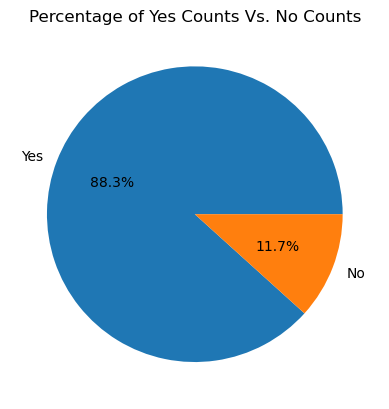

In [13]:
# Creating a visual summary of churn counts for the dataset
dataframe["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Yes Counts Vs. No Counts")
plt.ylabel("")
plt.show()

In [14]:
# Average Monthly chargers by Churn
dataframe.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [15]:
# Average Monthly chargers by Churn and gender
dataframe.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [16]:
# Average tenure by churn
dataframe.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [17]:
# Average age by churn
dataframe.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

In [18]:
# Average monthly charges by contract type
dataframe.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

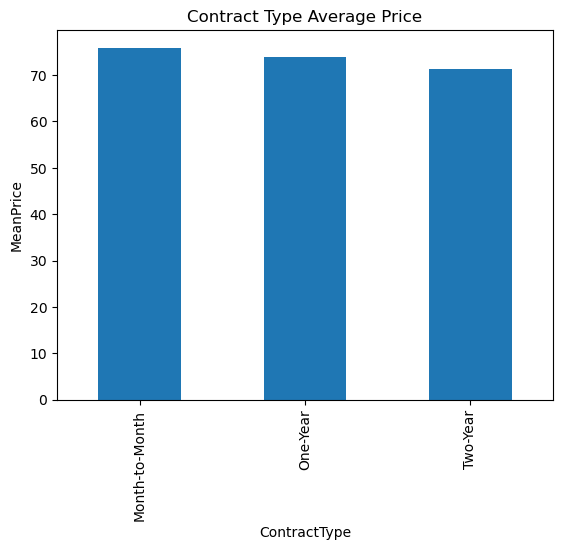

In [19]:
# Bar chart for average monthly charges by contract type
dataframe.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("MeanPrice")
plt.xlabel("ContractType")
plt.title("Contract Type Average Price")
plt.show()

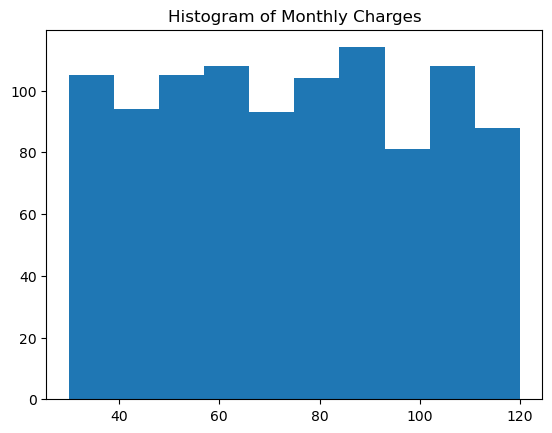

In [20]:
# Histogram of monthly charges (gives an idea of the distribution of the data)
plt.hist(dataframe["MonthlyCharges"])
plt.title("Histogram of Monthly Charges")
plt.show()


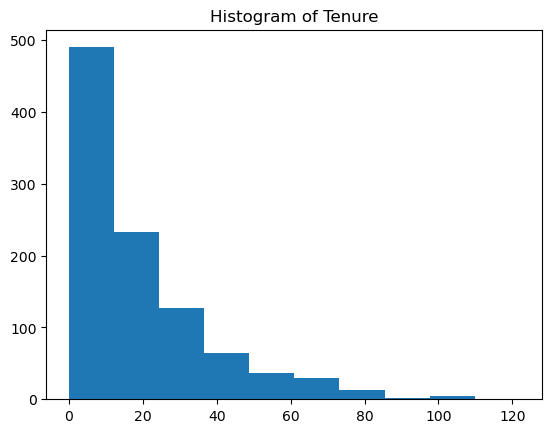

In [21]:
# Histogram of tenure (gives an idea of the distribution of the data)
plt.hist(dataframe["Tenure"])
plt.title("Histogram of Tenure")
plt.show()

In [22]:
# We will set the target variable (y) to be churn and the predictor variables (x) to represent Age, Gender, Tenure, Monthly Charges. We will begin analysis.
X = dataframe[["Age", "Gender", "Tenure", "MonthlyCharges"]]
y = dataframe["Churn"]

In [23]:
# The first step is to assign numerical values to the variables since that is a necessary step in machine learnign models.
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)
y = y.apply(lambda x: 1 if x == "Yes" else 0)
display(X.head())
display(y.head())

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

In [24]:
# Checking to make sure that all of our values are now numerical and not strings
print(type(X["Gender"].iloc[0]))
print(type(y.iloc[0]))

<class 'numpy.int64'>
<class 'numpy.int64'>


In [25]:
# We will not split the data into training and testing sets. The model we wil build will learn from the training set and then we will use the testing set as a metric to see how well the model performs on unseen data.
# We will use test_size = 0.2 which means 80% of the dataset to train and 20% to test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [26]:
# We will make sure that the numeric features are on similar scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
joblib.dump(scaler, "scaler.pkl")
X_test = scaler.fit_transform(X_test)

In [27]:
# Creating a function for the accuracy model (we create this function because it will be used multiple times)
def model_performance(predictions):
    return f"Accuracy score: {accuracy_score(y_test, predictions):.4f}"

In [28]:
# We will start with the logistic regression which is standard for binary classifications like we have (churn is yes or no in other words 1 or 0)
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_predictions = logistic_model.predict(X_test)
print(model_performance(y_predictions))

Accuracy score: 0.9100


In [29]:
# K-Nearest Neighbors with GridSearchCv basically answering the question: "Out of the options given, which setup has the best performance under cross-validation.
param_grid = {"n_neighbors": [3, 5, 7, 9],"weights": ["uniform", "distance"]}
grid_knn = GridSearchCV(KNeighborsClassifier(),param_grid=param_grid,cv=5)
grid_knn.fit(X_train, y_train)
print(grid_knn.best_params_)
y_predictions = grid_knn.predict(X_test)
print(model_performance(y_predictions))

{'n_neighbors': 9, 'weights': 'uniform'}
Accuracy score: 0.8950


In [30]:
# Support Vector Classifier with GridSearchCV (to test different values of C and different kernels)
svm = SVC()
param_grid = {"C": [0.01, 0.1, 0.5, 1],"kernel": ["linear", "rbf", "poly"]}
grid_svc = GridSearchCV(svm,param_grid=param_grid,cv=5)
grid_svc.fit(X_train, y_train)
print(grid_svc.best_params_)
y_predictions = grid_svc.predict(X_test)
print(model_performance(y_predictions))

{'C': 0.01, 'kernel': 'linear'}
Accuracy score: 0.9050


In [31]:
# Decision Tree with GridSearchCV (to capturenonlinear patterns and interactions)
param_grid = {"criterion": ["gini", "entropy"],"splitter": ["best", "random"],"max_depth": [None, 10, 20, 30],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4]}
grid_tree = GridSearchCV(DecisionTreeClassifier(),param_grid=param_grid,cv=5)
grid_tree.fit(X_train, y_train)
print(grid_tree.best_params_)
y_predictions = grid_tree.predict(X_test)
print(model_performance(y_predictions))

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
Accuracy score: 0.8850


In [32]:
# Random Forest with GridSearchCV
rfc_model = RandomForestClassifier()
param_grid = {"n_estimators": [32, 64, 128, 256],"max_features": [2, 3, 4],"bootstrap": [True, False]}
grid_rfc = GridSearchCV(rfc_model,param_grid=param_grid,cv=5)
grid_rfc.fit(X_train, y_train)
print(grid_rfc.best_params_)
y_predictions = grid_rfc.predict(X_test)
print(model_performance(y_predictions))

{'bootstrap': True, 'max_features': 2, 'n_estimators': 256}
Accuracy score: 0.9100


In [33]:
# Saving the best model (which in our case is the SVC model)
best_model = grid_svc.best_estimator_
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [34]:
# Printing the features so it is easier when creating the app
X.columns.tolist()

['Age', 'Gender', 'Tenure', 'MonthlyCharges']